In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils, alerceanomalies
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.svm import OneClassSVM
import distclassipy as dcpy
from distclassipy.anomaly import DistanceAnomaly
from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, OutlierMixin
epsilon = np.finfo(np.float32).eps
with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

from IPython.core.display import HTML
from IPython.display import display

import squarify
set3colors = [matplotlib.colors.rgb2hex(x) for x in plt.cm.Set3.colors]
knowncolors = set3colors[:4]
unknowncolors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9']
unknowncolors = set3colors[4:]+unknowncolors

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
models_to_test = {
    "DistClassiPy (min-median)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='median',
        normalize_scores=True
    ),
    
    "DistClassiPy (min-mean)": DistanceAnomaly(
        cluster_agg='min',
        metric_agg='mean',
        normalize_scores=True
    ),

    "IsolationForest": IsolationForest( #using alerce anomaly params
        n_estimators=100,
        max_samples=256,
        contamination=0.001,
        random_state=seed_val
    ),
    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=20, 
        novelty=True,  # IMPORTANT: Allows use on new data
        contamination='auto'
    ),
    
    "OneClassSVM": OneClassSVM(
        kernel='rbf',
        nu=0.001
    ),

    "Autoencoder": alerceanomalies.AutoencoderAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=500,
        patience=15,
    ),


    "Variational Autoencoder": alerceanomalies.VAEAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=500,
        patience=15,
        loss_samples=5 # Number of samples for the reconstruction term in ELBO
    ),

    "DeepSVDD": alerceanomalies.DeepSVDDAnomalyDetector(
        encoding_dim=32, # Can be tuned
        epochs=500,
        patience=15,
    ),

    "ClassSVDD": alerceanomalies.ClassSVDDAnomalyDetector(
        z_dim=64,
        epochs=500,
        patience=15,
        lr=1e-4,
        verbose=False
    )
}

In [3]:
traindat = pd.read_pickle("data/alercedata/train_data_filtered.pkl").set_index("oid")
testdat = pd.read_pickle("data/alercedata/test_data_filtered.pkl").set_index("oid")
feature_list = pd.read_pickle("data/alercedata/features_BHRF_model.pkl")

commondat = pd.concat([traindat,testdat])
commondat=commondat.rename(columns={"classALeRCE":"class"})

In [4]:
commondat["class"].unique()

array(['RRL', 'LPV', 'E', 'QSO', 'YSO', 'SNIa', 'AGN', 'CEP',
       'Periodic-Other', 'DSCT', 'Blazar', 'SNII', 'CV/Nova', 'SLSN',
       'SNIbc'], dtype=object)

In [5]:
new_knowns = ['SNIa', 'SNII', 'SNIbc']
new_unknowns = ["SLSN"]

features_to_use = [
"SPM_A_1",
"SPM_t0_1",
"SPM_gamma_1",
"SPM_beta_1",
"SPM_tau_rise_1",
"SPM_tau_fall_1",
"SPM_chi_1",
"SPM_A_2",
"SPM_t0_2",
"SPM_gamma_2",
"SPM_beta_2",
"SPM_tau_rise_2",
"SPM_tau_fall_2",
"SPM_chi_2",
]

In [6]:
subclasses = np.concatenate([new_knowns, new_unknowns])
top_level_df = commondat[commondat['class'].isin(subclasses)]
top_level_df = top_level_df.loc[:,list(features_to_use)+["class"]].dropna(subset=features_to_use)
top_level_df = top_level_df[~top_level_df.index.duplicated(keep='first')]

inlier_df = top_level_df[top_level_df["class"].isin(new_knowns)]

In [7]:
inlier_df["class"].value_counts()

class
SNIa     1901
SNII      615
SNIbc     131
Name: count, dtype: int64

In [8]:
smallest_class_count = inlier_df["class"].value_counts().min()
keep_indices = inlier_df.groupby("class").sample(smallest_class_count).index
inlier_df=inlier_df[inlier_df.index.isin(keep_indices)]
thrown_inlier_df = inlier_df[~inlier_df.index.isin(keep_indices)]

In [9]:
outlier_df = top_level_df[top_level_df["class"].isin(new_unknowns)]

In [10]:
outlier_df["class"].value_counts()

class
SLSN    75
Name: count, dtype: int64

In [11]:
# First split inliers into train/test
inlier_train_df, inlier_test_df = train_test_split(
    inlier_df, test_size=0.1, random_state=seed_val,
    stratify=inlier_df['class'],
)

In [12]:
tot_inliers_in_test = inlier_test_df["class"].value_counts().sum()

In [13]:
frac_outliers_in_test = 0.9
tot_outliers_in_test = int(frac_outliers_in_test * tot_inliers_in_test)

In [14]:
outlier_counts = outlier_df["class"].value_counts()
num_outlier_classes = len(outlier_counts)

In [15]:
num_outlier_classes

1

In [16]:
samples_to_take = {}
active_classes = list(outlier_counts.index)
remaining_to_sample = tot_outliers_in_test
available_counts = outlier_counts.copy()

while True:
    if not active_classes:
        break

    ideal_samples_per_class = remaining_to_sample / len(active_classes)
    
    # Find classes that have fewer members than the ideal number
    small_classes = [
        c for c in active_classes if available_counts[c] < ideal_samples_per_class
    ]

    if not small_classes:
        # No more small classes, proceed to final distribution
        break

    # For each small class, take all available members
    for class_name in small_classes:
        num_to_take = available_counts[class_name]
        samples_to_take[class_name] = num_to_take
        
        remaining_to_sample -= num_to_take
        active_classes.remove(class_name)

# 4. Distribute the rest of the samples among the larger classes
if active_classes:
    base_samples = remaining_to_sample // len(active_classes)
    remainder = remaining_to_sample % len(active_classes)

    for i, class_name in enumerate(active_classes):
        if i < remainder:
            samples_to_take[class_name] = base_samples + 1
        else:
            samples_to_take[class_name] = base_samples

# 5. Perform the actual sampling
sampled_dfs = []
for class_name, n_samples in samples_to_take.items():
    # Using .sample() to randomly select 'n_samples' from each class group
    class_df = outlier_df[outlier_df['class'] == class_name].sample(n=n_samples, random_state=42)
    sampled_dfs.append(class_df)

# Combine all the sampled data into a final DataFrame
final_sampled_df = pd.concat(sampled_dfs)

In [17]:
X_train_df = inlier_train_df[features_to_use]
y_train_df = inlier_train_df['class']

In [18]:
X_test_df = pd.concat([inlier_test_df[features_to_use], final_sampled_df[features_to_use]]).sample(frac=1)
y_test_df = pd.concat([inlier_test_df['class'], final_sampled_df['class']]).loc[X_test_df.index]

In [19]:
results_df = pd.DataFrame(index=X_test_df.index)
results_df['class'] = y_test_df
mask = results_df['class'].isin(new_knowns)
results_df['status'] = np.where(mask, 'normal', 'anomalous')

In [20]:
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [21]:
for model_name, model in tqdm(models_to_test.items(), desc=f"Models", leave=False):
    if "DistClassiPy" in model_name or "ClassSVDD" or "DeepSVDD" in model_name:
        model.fit(X_train_df.to_numpy(), y_train_df.to_numpy())
    else:
        model.fit(X_train_df.to_numpy())
    scores = model.decision_function(X_test_df.to_numpy())
    if model_name in ["IsolationForest", "LocalOutlierFactor", "OneClassSVM"]:
        scores = -scores # Lower is more anomalous for these, so we flip

    results_df[f'score_{model_name}'] = scores

Models:   0%|          | 0/9 [00:00<?, ?it/s]

Training AE:   0%|          | 0/500 [00:00<?, ?it/s]

Early stopping triggered.


Training VAE:   0%|          | 0/500 [00:00<?, ?it/s]

Early stopping triggered.


Training DeepSVDD:   0%|          | 0/500 [00:00<?, ?it/s]

Early stopping triggered.


Training ClassSVDD:   0%|          | 0/500 [00:00<?, ?it/s]

Early stopping triggered.


In [22]:
max_anom = results_df["status"].value_counts()["anomalous"]
# top_n = min(top_n_min, max_anom)
top_n = max_anom

In [23]:
results_df.sort_values(by="score_DistClassiPy (min-median)",ascending=False)

,class,status,score_DistClassiPy (min-median),score_DistClassiPy (min-mean),score_IsolationForest,score_LocalOutlierFactor,score_OneClassSVM,score_Autoencoder,score_Variational Autoencoder,score_DeepSVDD,score_ClassSVDD
oid,,,,,,,,,,,
ZTF20aaurzyt,SLSN,anomalous,1.000000,0.966995,-0.056285,0.188670,0.000202,63539.843750,64819.406250,1.398522,144.925293
ZTF20aceicyy,SLSN,anomalous,0.699923,0.644521,-0.177789,-0.050575,0.000122,29016.351562,29831.945312,1.207852,130.750870
ZTF19acdabep,SNIbc,normal,0.692799,0.609126,-0.323875,-0.442632,0.000149,615.943726,731.867188,5.981631,72.612839
ZTF20acgyjbh,SNII,normal,0.685933,0.667932,-0.134633,0.131398,0.000148,46864.246094,47866.433594,1.693691,150.573151
ZTF20aclnqle,SLSN,anomalous,0.616391,0.580906,-0.178316,-0.117874,0.000141,39079.738281,39976.617188,1.367696,149.726379
...,...,...,...,...,...,...,...,...,...,...,...
ZTF20abzoeiw,SNIbc,normal,0.062089,0.110332,-0.376048,-0.509650,0.000131,1770.965210,1927.724487,3.983480,78.862488
ZTF20acqlcge,SNIa,normal,0.052818,0.101260,-0.381994,-0.340775,0.000116,2860.877441,3061.282715,2.697966,84.928352
ZTF20aattyuz,SLSN,anomalous,0.046441,0.127567,-0.385120,-0.330337,0.000120,2711.381592,2870.944336,3.496891,78.717377


method:   0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

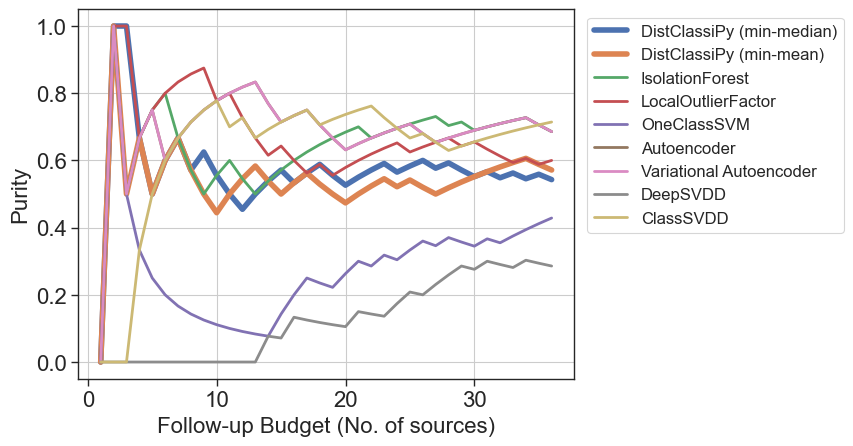

In [24]:
methods_percent = {}
top_ns = np.arange(start=1, stop=top_n+1)

for model_name in tqdm(models_to_test.keys(),desc="method",leave=False):
    methods_percent[model_name] = []
    topresults_df = results_df.sort_values(by=f"score_{model_name}",ascending=False).iloc[:top_n]
    for i in tqdm(range(len(topresults_df)), leave=False):
        top_candidates = topresults_df.head(i)
        valcounts = top_candidates['status'].value_counts(normalize=True,ascending=True)
        if "anomalous" in valcounts.index:
            frac = valcounts["anomalous"]
            # frac = valcounts["anomalous"] / len(y_anom_df)
        else:
            frac = 0
        methods_percent[model_name].append(frac)
    if "distclassipy" in model_name.lower():
        lw=4
    else:
        lw=2
    plt.plot(top_ns, methods_percent[model_name][:top_n], label=model_name, linewidth=lw)
plt.ylabel("Purity", fontsize=16)
plt.xlabel("Follow-up Budget (No. of sources)", fontsize=16)
plt.gca().tick_params(axis='both', which='major', labelsize=16)
plt.gca().tick_params(axis='both', which='minor', labelsize=12)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
plt.savefig("06. paper neurips mlps/EXP2.pdf", bbox_inches="tight")
plt.show()